In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('cloud/train.csv')
data.isnull().sum()

Image_Label          0
EncodedPixels    10348
dtype: int64

In [3]:
image_ids = data['Image_Label'].str.rsplit('_', n=1).str[1]
unique_image_names = image_ids.unique()
unique_image_names

array(['Fish', 'Flower', 'Gravel', 'Sugar'], dtype=object)

In [4]:
# ------------------------------------------------------------
# 1. ПРОСТОЙ DATASET (без negative strides)
# ------------------------------------------------------------
class CloudDataset(Dataset):
    def __init__(self, data, image_dir):
        self.data = data
        self.image_dir = image_dir
        self.ids = data['Image_Label'].apply(lambda x: x.split('_')[0]).unique()
        self.classes = ['Sugar', 'Gravel', 'Flower', 'Fish']

    def __len__(self):
        return len(self.ids)
    
    def rle_decode(self, rle, shape):
        if pd.isna(rle) or rle == '-1':
            return np.zeros(shape, dtype=np.uint8)
        
        s = rle.split()
        starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
        starts -= 1
        ends = starts + lengths

        img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
        for lo, hi in zip(starts, ends):
            img[lo:hi] = 1

        return img.reshape(shape, order='F')

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # --- IMAGE ---
        img = cv2.imread(os.path.join(self.image_dir, img_id))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- MASK (ВАЖНО!) ---
        mask = np.zeros((1400, 2100, 4), dtype=np.uint8)

        for i, cls in enumerate(self.classes):
            row = self.data[self.data['Image_Label'] == f"{img_id}_{cls}"]
            if not row.empty:
                rle = row['EncodedPixels'].values[0]
                mask[:, :, i] = self.rle_decode(rle, (1400, 2100))

        # --- RESIZE (после decode!) ---
        img = cv2.resize(img, (256, 256))
        mask_resized = np.zeros((256, 256, 4), dtype=np.float32)

        for i in range(4):
            mask_resized[:, :, i] = cv2.resize(
                mask[:, :, i],
                (256, 256),
                interpolation=cv2.INTER_NEAREST  # ВАЖНО!
            )

        # --- TO TENSOR ---
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        # mask = torch.from_numpy(mask_resized).permute(2, 0, 1).float()
        mask_indices = np.argmax(mask_resized, axis=2)  # [256, 256] со значениями 0-3
        mask = torch.from_numpy(mask_indices).long()
        

        return img, mask


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu1 = nn.LeakyReLU(0.01, inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu2 = nn.LeakyReLU(0.01, inplace=True)
        
        # Skip connection
        self.skip = nn.Sequential()
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = self.skip(x)
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        out += identity
        out = self.relu2(out)
        
        return out


class AdvancedSegCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        # ========== ЭНКОДЕР (ResBlock'и) ==========
        self.enc1 = ResBlock(3, 16)          # 256×256
        self.pool = nn.MaxPool2d(2, 2)
        
        self.enc2 = ResBlock(16, 32)         # 128×128
        self.enc3 = ResBlock(32, 64)         # 64×64
        self.enc4 = ResBlock(64, 128)        # 32×32
        
        self.dropout = nn.Dropout2d(0.25)
        
        # ========== ДЕКОДЕР (Upsample + ResBlock) ==========
        # 16×16 → 32×32
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 64, 3, padding=1)
        )
        self.dec1 = ResBlock(64, 64)
        
        # 32×32 → 64×64
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1)
        )
        self.dec2 = ResBlock(32, 32)
        
        # 64×64 → 128×128
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1)
        )
        self.dec3 = ResBlock(16, 16)
        
        # 128×128 → 256×256
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(16, 16, 3, padding=1)
        )
        self.dec4 = ResBlock(16, 16)
        
        self.out = nn.Conv2d(16, 4, 1)
    
    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                           # 256×256, 16 каналов
        e2 = self.enc2(self.pool(e1))               # 128×128, 32 канала
        e3 = self.enc3(self.pool(e2))               # 64×64, 64 канала
        e4 = self.enc4(self.pool(e3))               # 32×32, 128 каналов
        x = self.pool(e4)                            # 16×16, 128 каналов
        
        x = self.dropout(x)
        
        # Decoder
        x = self.dec1(self.up1(x))                  # 16→32, 128→64
        x = self.dec2(self.up2(x))                  # 32→64, 64→32
        x = self.dec3(self.up3(x))                  # 64→128, 32→16
        x = self.dec4(self.up4(x))                  # 128→256, 16→16
        
        return self.out(x)



In [6]:
# ------------------------------------------------------------
# 3. ЗАГРУЗКА И ПРОВЕРКА
# ------------------------------------------------------------
image_dir = 'cloud/train_images'

# Создаём ОДИН датасет из train
full_dataset = CloudDataset(data, image_dir)

# Разделяем на train/val
from sklearn.model_selection import train_test_split

all_ids = data['Image_Label'].apply(lambda x: x.split('_')[0]).unique()
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)

train_data = data[data['Image_Label'].apply(lambda x: x.split('_')[0]).isin(train_ids)]
val_data = data[data['Image_Label'].apply(lambda x: x.split('_')[0]).isin(val_ids)]

train_dataset = CloudDataset(train_data, image_dir)
val_dataset = CloudDataset(val_data, image_dir)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_dataset)} images, Val: {len(val_dataset)} images")

Train: 4436 images, Val: 1110 images


In [7]:
# ------------------------------------------------------------
# 5. ФУНКЦИЯ ПОТЕРЬ И МЕТРИКА DICE
# ------------------------------------------------------------
def dice_score(pred, target, smooth=1e-6):
    """
    pred: [batch, 4, 256, 256] — логиты от модели
    target: [batch, 256, 256] — индексы классов (0-3)
    """
    # Превращаем логиты в индексы классов
    pred_classes = torch.argmax(pred, dim=1)  # [batch, 256, 256]
    
    # Превращаем индексы в one-hot для подсчёта Dice
    pred_one_hot = F.one_hot(pred_classes, num_classes=4).permute(0, 3, 1, 2).float()
    target_one_hot = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    
    intersection = (pred_one_hot * target_one_hot).sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (pred_one_hot.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3)) + smooth)
    return dice.mean().item()

def dice_loss(pred, target, smooth=1e-6):
#     pred = torch.sigmoid(pred)#pred.contiguous()
#     pred = (pred > 0.5).float()# target = target.contiguous()
    
#     intersection = (pred * target).sum(dim=(2,3))
#     union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    
#     dice = (2. * intersection + smooth) / (union + smooth)
    
#     return 1 - dice.mean()
    pred_soft = F.softmax(pred, dim=1)  # ← Softmax для 4 классов
    target_one_hot = F.one_hot(target, num_classes=4).permute(0, 3, 1, 2).float()
    
    intersection = (pred_soft * target_one_hot).sum(dim=(2, 3))
    union = pred_soft.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()  # ← Градиент течёт через pred_soft!

In [83]:
def calculate_weights(dataset):
    total_pixels = 0
    class_pixels = [0, 0, 0, 0]
    
    for idx in range(len(dataset)):
        _, mask = dataset[idx]
        total_pixels += 256 * 256
        for i in range(4):
            class_pixels[i] += mask[i].sum().item()
    
    weights = []
    for pixels in class_pixels:
        neg = total_pixels - pixels
        w = neg / (pixels + 1)  # +1 чтобы не делить на ноль
        weights.append(min(w, 15.0))
    
    return torch.tensor(weights)

pos_weights = calculate_weights(train_dataset).to(device)

In [10]:
device = torch.device('mps')
print(f"Device: {device}")
# pos_weights = pos_weights.view(1, 4, 1, 1)
model = AdvancedSegCNN().to(device)
# model = ResNet18().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# bce_loss = nn.BCELoss()
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
criterion = nn.CrossEntropyLoss()

# Для графиков
history = {'train_loss': [], 'val_dice': []}

# Early stopping
best_dice = 0
patience = 7
counter = 0

epochs = 30

for epoch in range(epochs):
    # Тренировка
    model.train()
    train_loss = 0.0
    
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        # print("outputs:", outputs.shape)
        # print("masks:", masks.shape)
        # if masks.shape[1] != 4:
        #     masks = masks.permute(0, 3, 1, 2)
        # Комбинированный лосс
        loss = criterion(outputs, masks) + 0.1 * dice_loss(outputs, masks)
        loss.backward()
        optimizer.step()

        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)
    
    # Валидация
    model.eval()
    val_dice_sum = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_dice_sum += dice_score(outputs, masks)
    
    val_dice = val_dice_sum / len(val_loader)
    history['val_dice'].append(val_dice)
    
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {train_loss:.4f} | Val Dice: {val_dice:.4f}")
    
    # Early stopping
    if val_dice > best_dice or train_loss < min(history['train_loss']):
        best_dice = val_dice
        torch.save(model.state_dict(), 'best_model_reset.pth')
        counter = 0
        print(f"  ✅ Saved! Best Dice: {best_dice:.4f}")
    # else:
    #     counter += 1
    #     if counter >= patience:
    #         print(f"  🛑 Early stopping at epoch {epoch+1}")
    #         break

print(f"\nОбучение завершено. Лучший Dice: {best_dice:.4f}")

Device: mps
Epoch  1/30 | Loss: 0.9899 | Val Dice: 0.5165
  ✅ Saved! Best Dice: 0.5165
Epoch  2/30 | Loss: 0.8499 | Val Dice: 0.5175
  ✅ Saved! Best Dice: 0.5175
Epoch  3/30 | Loss: 0.8291 | Val Dice: 0.5088
Epoch  4/30 | Loss: 0.8135 | Val Dice: 0.5322
  ✅ Saved! Best Dice: 0.5322
Epoch  5/30 | Loss: 0.7992 | Val Dice: 0.5925
  ✅ Saved! Best Dice: 0.5925
Epoch  6/30 | Loss: 0.7863 | Val Dice: 0.5898
Epoch  7/30 | Loss: 0.7837 | Val Dice: 0.5855
Epoch  8/30 | Loss: 0.7757 | Val Dice: 0.5983
  ✅ Saved! Best Dice: 0.5983
Epoch  9/30 | Loss: 0.7685 | Val Dice: 0.5179
Epoch 10/30 | Loss: 0.7640 | Val Dice: 0.5905
Epoch 11/30 | Loss: 0.7568 | Val Dice: 0.5485
Epoch 12/30 | Loss: 0.7524 | Val Dice: 0.5619
Epoch 13/30 | Loss: 0.7466 | Val Dice: 0.5443
Epoch 14/30 | Loss: 0.7379 | Val Dice: 0.5589
Epoch 15/30 | Loss: 0.7274 | Val Dice: 0.5353
Epoch 16/30 | Loss: 0.7223 | Val Dice: 0.5619
Epoch 17/30 | Loss: 0.7107 | Val Dice: 0.6020
  ✅ Saved! Best Dice: 0.6020
Epoch 18/30 | Loss: 0.7084 | Val

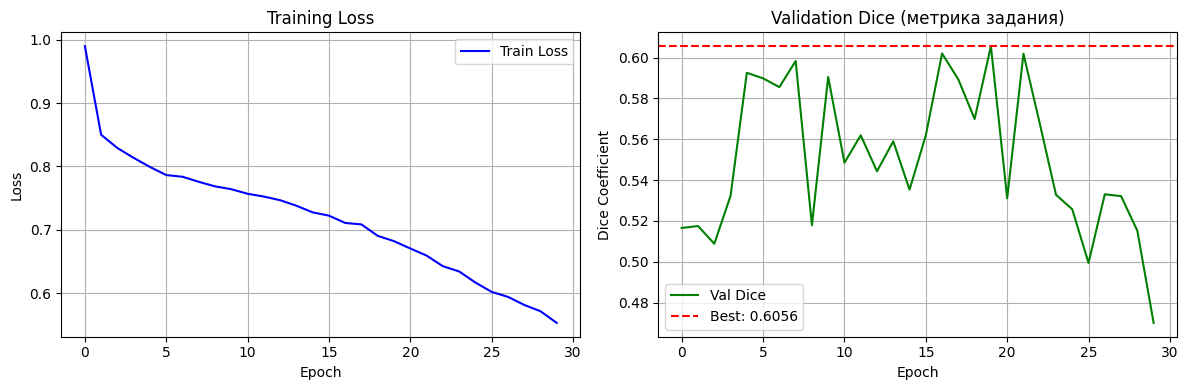

In [11]:
# ------------------------------------------------------------
# 7. ГРАФИК ОБУЧЕНИЯ 
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], 'b-', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['val_dice'], 'g-', label='Val Dice')
ax2.axhline(y=best_dice, color='r', linestyle='--', label=f'Best: {best_dice:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Coefficient')
ax2.set_title('Validation Dice (метрика задания)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [38]:
# ------------------------------------------------------------
# 8. ФИНАЛЬНАЯ ОЦЕНКА (загружаем лучшую модель)
# ------------------------------------------------------------
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

final_dice = 0.0
with torch.no_grad():
    for images, masks in val_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        final_dice += dice_score(outputs, masks)

print(f"Финальный Dice на валидации: {final_dice / len(val_loader):.4f}")

Финальный Dice на валидации: 0.2832


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def predict_and_show(model, dataset, idx, device='mps'):
    """
    Показывает оригинальную картинку, истинную маску и предсказание модели
    
    model: обученная модель
    dataset: датасет (train или val)
    idx: индекс картинки в датасете
    """
    model.eval()
    
    # Берём картинку и маску из датасета
    image, true_mask = dataset[idx]
    
    # Добавляем размерность batch (1, C, H, W)
    image_batch = image.unsqueeze(0).to(device)
    
    # Предсказание
    with torch.no_grad():
        pred_mask = model(image_batch)
        pred_mask = pred_mask.cpu().squeeze(0)
        pred_classes = torch.argmax(pred_mask, dim=0)  # [256, 256] индексы классов
    
    # Классы облаков
    classes = ['Sugar', 'Gravel', 'Flower', 'Fish']
    
    # Рисуем
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # 1. Оригинальная картинка
    img_show = image.permute(1, 2, 0).numpy()
    # Денормализация если была нормализация
    img_show = np.clip(img_show, 0, 1)
    axes[0, 0].imshow(img_show)
    axes[0, 0].set_title('Оригинал')
    axes[0, 0].axis('off')
    
    # 2. Комбинированная истинная маска (все классы разными цветами)
    true_combined = np.zeros((256, 256, 3))
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]  # Красный, Зеленый, Синий, Желтый
    
    for i in range(4):
        mask_channel = (true_mask.numpy() == i)
        for c in range(3):
            true_combined[:, :, c] += mask_channel * colors[i][c] / 255.0
    
    axes[0, 1].imshow(np.clip(true_combined, 0, 1))
    axes[0, 1].set_title('Истинная маска')
    axes[0, 1].axis('off')
    
    # 3. Комбинированная предсказанная маска
    pred_combined = np.zeros((256, 256, 3))
    for i in range(4):
        mask_channel = (pred_classes.numpy() == i)
        for c in range(3):
            pred_combined[:, :, c] += mask_channel * colors[i][c] / 255.0
    
    axes[0, 2].imshow(np.clip(pred_combined, 0, 1))
    axes[0, 2].set_title('Предсказание')
    axes[0, 2].axis('off')
    
    # 4. Пустые ячейки
    axes[0, 3].axis('off')
    axes[0, 4].axis('off')
    
    # 5. Отдельные классы (истина vs предсказание)
    for i, class_name in enumerate(classes):
        # Истина
        axes[1, i].imshow((true_mask.numpy() == i), cmap='gray')
        axes[1, i].set_title(f'{class_name} (True)')
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Считаем Dice для каждого класса
    print("Dice Score по классам:")
    for i, class_name in enumerate(classes):
        pred = (pred_classes.numpy() == i).astype(np.float32).flatten()
        true = (true_mask.numpy() == i).astype(np.float32).flatten()
        intersection = (pred * true).sum()
        dice = 2 * intersection / (pred.sum() + true.sum() + 1e-6)
        print(f"  {class_name}: {dice:.4f}")

TypeError: can't convert mps:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

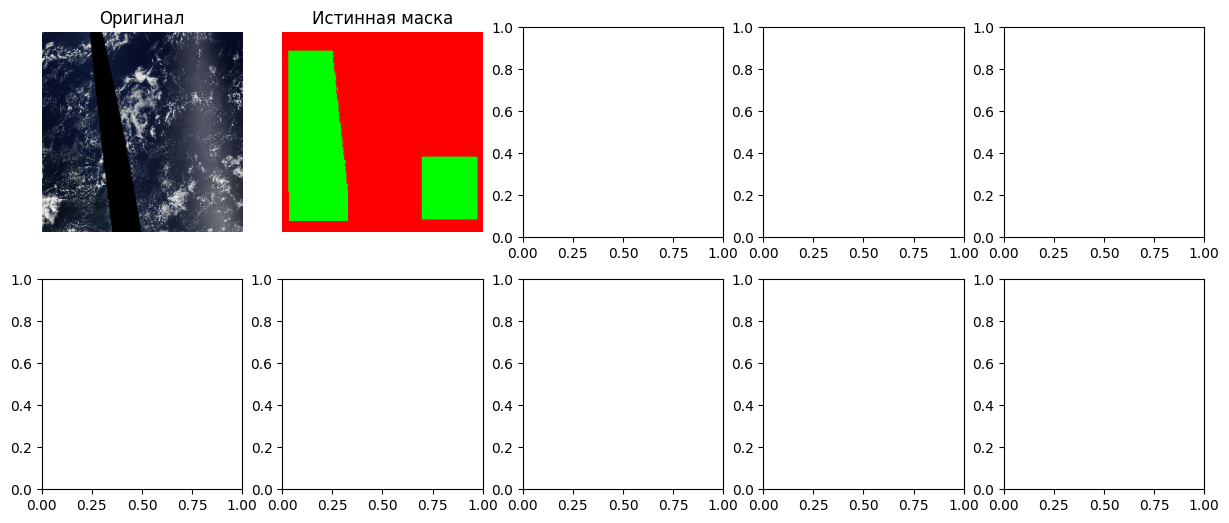

In [14]:
# Загружаем лучшую модель
model.load_state_dict(torch.load('best_model_reset.pth', map_location=device))
model.to(device)

# Показываем случайный пример из валидации
import random
idx = random.randint(0, len(val_dataset) - 1)
predict_and_show(model, val_dataset, idx, device)